## Import Library

In [89]:
import pandas as pd
import json

## Load Dataset

In [90]:
df = pd.read_csv("./dataset_hasil_preprocessing/dataset.csv")

In [91]:
df_label_from_rating = df
df_label_from_lexicon = df

## Labelling Berdasarkan Rating

In [92]:
def rating_to_label(x):
    if x == 5:
        return "positif"
    elif x == 4:
        return "netral"
    else:
        return "negatif"

df_label_from_rating["label"] = df_label_from_rating["rating"].apply(rating_to_label)

# Drop kolom rating
df_label_from_rating = df_label_from_rating.drop(columns=["rating"])

In [93]:
df_label_from_rating["label"].value_counts()

label
negatif    3331
positif    1200
netral      629
Name: count, dtype: int64

In [94]:
df_output2 = df_label_from_rating[["username","review", "tahun", "aplikasi", "clean_text", "label"]]

In [95]:
df_output2.to_csv(
    "./dataset_oke/dataset_label_rating.csv",
    index=False,
    encoding="utf-8"
)


## Labelling Menggunakan Lexicon


In [96]:
with open("./help-data/lexicon.json", "r", encoding="utf-8") as f:
    lexicon = json.load(f)


In [97]:
df_label_from_lexicon["tokens"] = df_label_from_lexicon["clean_text"].str.split()


In [98]:
def hitung_skor(tokens, lexicon):
    if not isinstance(tokens, list):
        return 0
    skor = 0
    for kata in tokens:
        skor += lexicon.get(kata, 0)
    return skor


def label_sentimen(skor):
    if skor > 0:
        return "positif"
    if skor < 0:
        return "negatif"
    return "netral"


In [99]:
df_label_from_lexicon["sentiment_score"] = df_label_from_lexicon["tokens"].apply(
    lambda x: hitung_skor(x, lexicon)
)

df_label_from_lexicon["label"] = df_label_from_lexicon["sentiment_score"].apply(
    lambda x: label_sentimen(x)
)


In [100]:
df_label_from_lexicon["label"].value_counts()

label
netral     2644
negatif    1436
positif    1080
Name: count, dtype: int64

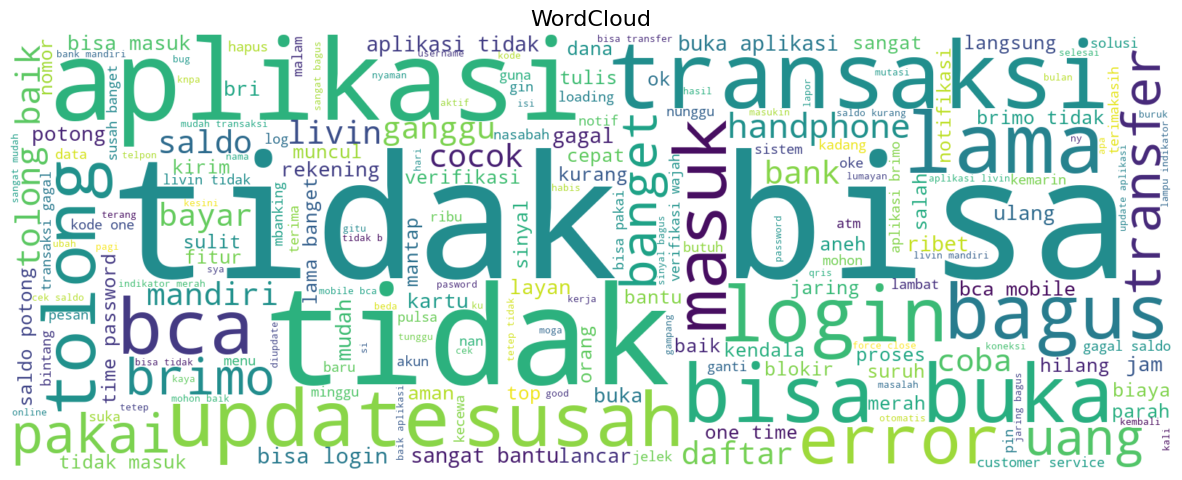

In [101]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(
    df_label_from_lexicon["clean_text"].astype(str).tolist()
)


# Buat WordCloud
wc = WordCloud(
    width=1600,
    height=600,
    background_color="white",
).generate(all_text)

# Tampilkan
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud", fontsize=16)
plt.show()

In [102]:
df.columns

Index(['username', 'review', 'rating', 'tahun', 'aplikasi', 'clean_text',
       'label', 'tokens', 'sentiment_score'],
      dtype='object')

In [103]:
df_output = df_label_from_lexicon[["username","review", "tahun", "aplikasi", "clean_text", "sentiment_score", "label"]]


In [104]:
df_output.to_csv(
    "./dataset_oke/dataset_label_lexicon.csv",
    index=False,
    encoding="utf-8"
)
